<a href="https://colab.research.google.com/github/sreent/machine-learning/blob/main/Mid-Term%20Coursework%20Example.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data Preprocessing and EDA
This section involves loading the dataset, splitting it into training and testing sets, and standardizing the features. Standardization ensures that all features contribute equally to distance-based calculations in algorithms like kNN and logistic regression [1][2].

In [26]:
# Import necessary libraries
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
from collections import Counter
import numpy as np
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.manifold import TSNE

# Load the dataset
iris = load_iris()
X = iris.data
y = iris.target

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Exploratory Data Analysis (EDA)
# Create a DataFrame for easier visualization
df = pd.DataFrame(X, columns=iris.feature_names)
df['species'] = y

#### Class Balance
The bar plot of class distribution shows that the dataset is balanced, with 50 samples for each species. This balance justifies the use of accuracy as a metric for evaluating our models, as each class is equally represented [1].


In [9]:
# Check class balance
class_counts = df['species'].value_counts()
print("Class counts:\n", class_counts)

Class counts:
 species
0    50
1    50
2    50
Name: count, dtype: int64


#### Pair Plot
The pair plot visualizes the relationships between all feature pairs and how they relate to the target class. This helps in identifying potential patterns and separability among the classes.


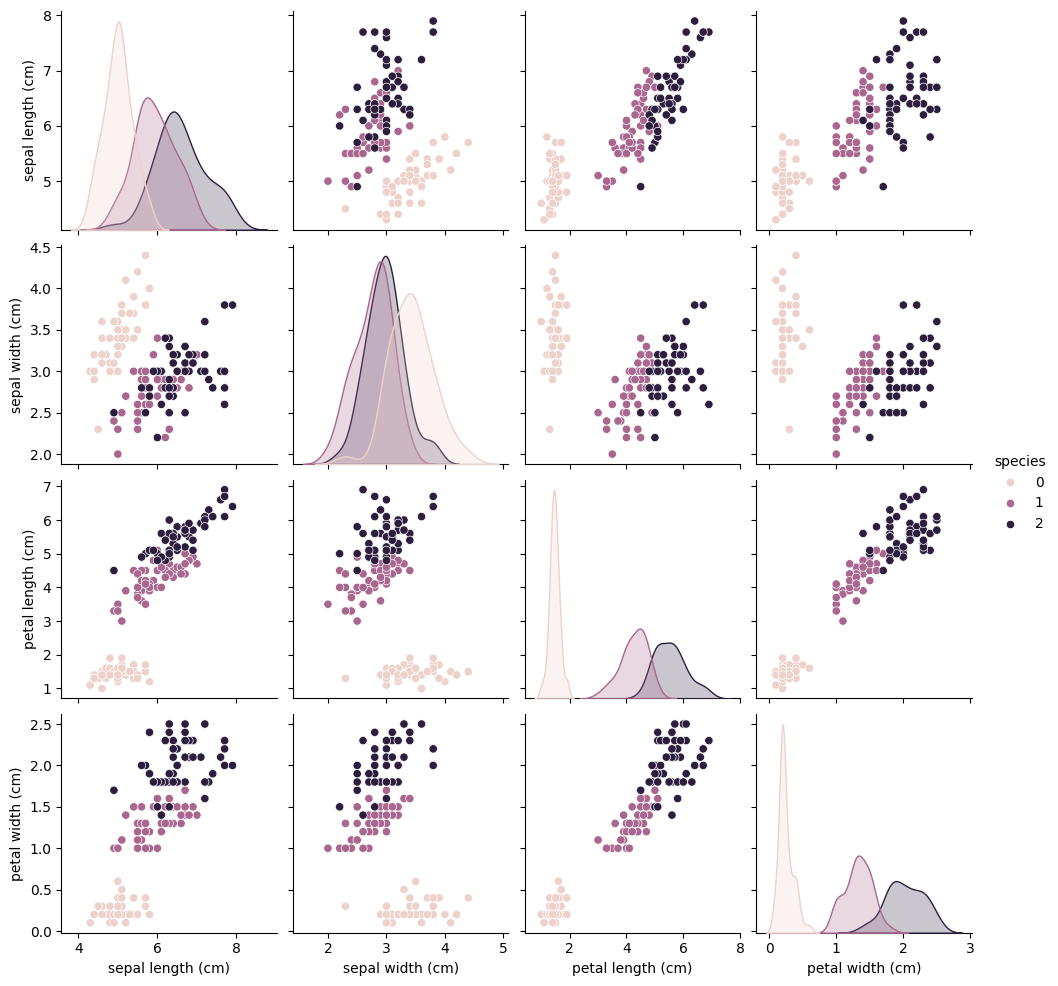

In [3]:
# Pairplot to visualize relationships between features
sns.pairplot(df, hue='species')
plt.show()

#### Correlation Heatmap
The correlation heatmap displays the correlation coefficients between the features. Features with high correlation coefficients can provide redundant information, while low correlations suggest independent information. This is crucial for understanding feature importance later [3].


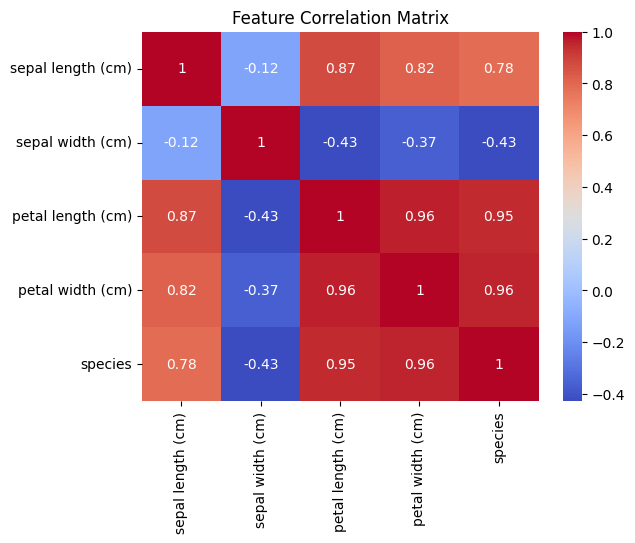

In [4]:
# Correlation heatmap
corr_matrix = df.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Feature Correlation Matrix')
plt.show()

#### t-SNE Visualization
t-SNE (t-distributed Stochastic Neighbor Embedding) is used to visualize the dataset in two dimensions, helping us understand the separability of the classes. This visualization supports the discussion on why the models perform well on the Iris dataset [4].

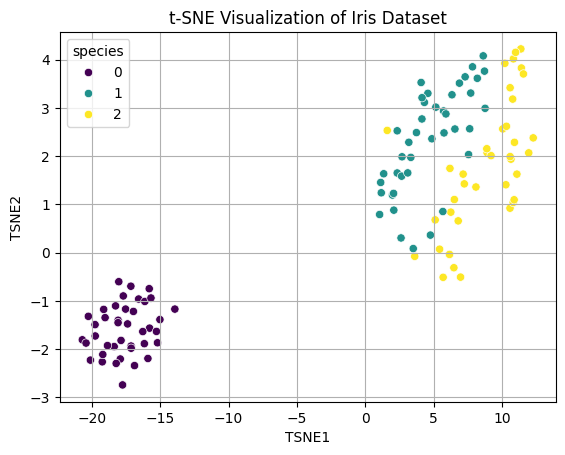

In [12]:
# t-SNE visualization
tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(X_train)

# Create a DataFrame for t-SNE results
df_tsne = pd.DataFrame(X_tsne, columns=['TSNE1', 'TSNE2'])
df_tsne['species'] = y_train

# Plot t-SNE results
sns.scatterplot(x='TSNE1', y='TSNE2', hue='species', palette='viridis', data=df_tsne)
plt.title('t-SNE Visualization of Iris Dataset')
plt.grid()
plt.show()

### Model Implementation and Evaluation
In this section, we implement the kNN and Naive Bayes classifiers from scratch, while using scikit-learn's implementations for the decision tree and logistic regression models. We also perform hyperparameter tuning using GridSearchCV for the kNN and logistic regression models to find the optimal parameters [5].


#### Custom k-NN Classifier
The kNN classifier is implemented as a custom scikit-learn estimator. We perform hyperparameter tuning to find the optimal value of k using GridSearchCV [6].


Best Parameters for Custom k-NN: {'k': 3}
Best Custom k-NN Model Performance
Accuracy: 1.00
Precision: 1.00
Recall: 1.00
F1 Score: 1.00

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



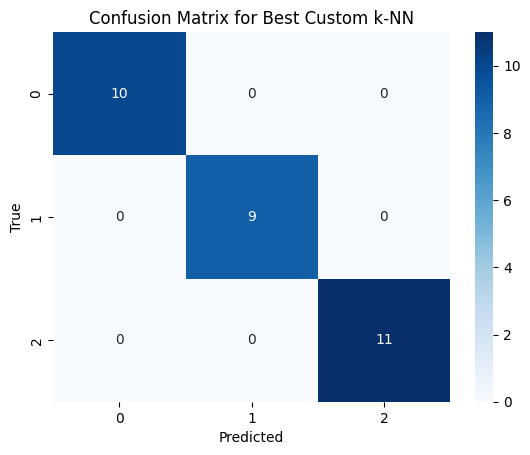

In [13]:
# Implementing Custom k-NN Classifier with Hyperparameter Tuning
from sklearn.base import BaseEstimator, ClassifierMixin
from collections import Counter
import numpy as np

class CustomKNNClassifier(BaseEstimator, ClassifierMixin):
    def __init__(self, k=3):
        self.k = k

    def fit(self, X, y):
        # Store the training data
        self.X_train = X
        self.y_train = y
        return self

    def predict(self, X):
        y_pred = []
        for x in X:
            distances = [np.sqrt(np.sum((x - x_train) ** 2)) for x_train in self.X_train]
            k_indices = np.argsort(distances)[:self.k]
            k_nearest_labels = [self.y_train[i] for i in k_indices]
            most_common = Counter(k_nearest_labels).most_common(1)
            y_pred.append(most_common[0][0])
        return np.array(y_pred)

# Perform GridSearchCV for hyperparameter tuning of custom k-NN
param_grid_knn = {'k': [1, 3, 5, 7, 9]}
grid_search_knn = GridSearchCV(CustomKNNClassifier(), param_grid_knn, cv=5, scoring='accuracy')
grid_search_knn.fit(X_train, y_train)

# Get the best model from grid search
best_knn = grid_search_knn.best_estimator_
print(f'Best Parameters for Custom k-NN: {grid_search_knn.best_params_}')

# Train and evaluate the best custom k-NN model on the entire training set
best_knn.fit(X_train, y_train)

# Predict on the test set for custom k-NN
y_pred_best_knn = best_knn.predict(X_test)

# Evaluate the best custom k-NN model
accuracy_best_knn = accuracy_score(y_test, y_pred_best_knn)
precision_best_knn = precision_score(y_test, y_pred_best_knn, average='weighted')
recall_best_knn = recall_score(y_test, y_pred_best_knn, average='weighted')
f1_best_knn = f1_score(y_test, y_pred_best_knn, average='weighted')

print("Best Custom k-NN Model Performance")
print(f"Accuracy: {accuracy_best_knn:.2f}")
print(f"Precision: {precision_best_knn:.2f}")
print(f"Recall: {recall_best_knn:.2f}")
print(f"F1 Score: {f1_best_knn:.2f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred_best_knn))

# Confusion Matrix for best custom k-NN
conf_matrix_best_knn = confusion_matrix(y_test, y_pred_best_knn)
sns.heatmap(conf_matrix_best_knn, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix for Best Custom k-NN')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.savefig('confusion_matrix_best_knn.png')
plt.show()

#### Custom Naive Bayes Classifier
The Naive Bayes classifier is implemented as a custom scikit-learn estimator. We evaluate its performance using cross-validation [7].


In [15]:
# Implementing Custom Naive Bayes Classifier with Hyperparameter Tuning
from sklearn.base import BaseEstimator, ClassifierMixin
import numpy as np

class CustomNaiveBayes(BaseEstimator, ClassifierMixin):
    def fit(self, X, y):
        self.classes = np.unique(y)
        self.mean = {}
        self.var = {}
        self.priors = {}

        for c in self.classes:
            X_c = X[y == c]
            self.mean[c] = X_c.mean(axis=0)
            self.var[c] = X_c.var(axis=0)
            self.priors[c] = X_c.shape[0] / X.shape[0]

        return self

    def predict(self, X):
        y_pred = []
        for x in X:
            posteriors = []
            for c in self.classes:
                prior = np.log(self.priors[c])
                class_conditional = np.sum(np.log(self._pdf(c, x)))
                posterior = prior + class_conditional
                posteriors.append(posterior)
            y_pred.append(self.classes[np.argmax(posteriors)])
        return np.array(y_pred)

    def _pdf(self, class_idx, x):
        mean = self.mean[class_idx]


 var = self.var[class_idx]
        numerator = np.exp(-(x - mean) ** 2 / (2 * var))
        denominator = np.sqrt(2 * np.pi * var)
        return numerator / denominator

# Perform 5-fold cross-validation for custom Naive Bayes
custom_nb = CustomNaiveBayes()
cv_scores_nb = cross_val_score(custom_nb, X_train, y_train, cv=5, scoring='accuracy')
print(f'Custom Naive Bayes Cross-Validation Accuracy: {cv_scores_nb.mean():.2f} ± {cv_scores_nb.std():.2f}')

# Train and evaluate the custom Naive Bayes model on the entire training set
custom_nb.fit(X_train, y_train)

# Predict on the test set for custom Naive Bayes
y_pred_custom_nb = custom_nb.predict(X_test)

# Evaluate the custom Naive Bayes model
accuracy_custom_nb = accuracy_score(y_test, y_pred_custom_nb)
precision_custom_nb = precision_score(y_test, y_pred_custom_nb, average='weighted')
recall_custom_nb = recall_score(y_test, y_pred_custom_nb, average='weighted')
f1_custom_nb = f1_score(y_test, y_pred_custom_nb, average='weighted')

print("Custom Naive Bayes Model Performance")
print(f"Accuracy: {accuracy_custom_nb:.2f}")
print(f"Precision: {precision_custom_nb:.2f}")
print(f"Recall: {recall_custom_nb:.2f}")
print(f"F1 Score: {f1_custom_nb:.2f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred_custom_nb))

# Confusion Matrix for custom Naive Bayes
conf_matrix_custom_nb = confusion_matrix(y_test, y_pred_custom_nb)
sns.heatmap(conf_matrix_custom_nb, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix for Custom Naive Bayes')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.savefig('confusion_matrix_custom_nb.png')
plt.show()

IndentationError: unindent does not match any outer indentation level (<tokenize>, line 36)

#### Decision Tree and Logistic Regression
We use scikit-learn's implementations of the decision tree and logistic regression models. For logistic regression, we perform hyperparameter tuning using GridSearchCV to find the optimal parameters [8].


Decision Tree Cross-Validation Accuracy: 0.94 ± 0.04
Decision Tree Model Performance
Accuracy: 1.00
Precision: 1.00
Recall: 1.00
F1 Score: 1.00

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



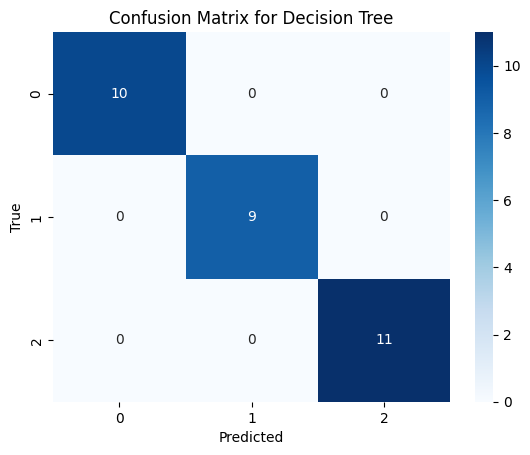

Best Parameters for Logistic Regression: {'C': 1, 'solver': 'lbfgs'}
Logistic Regression Model Performance
Accuracy: 1.00
Precision: 1.00
Recall: 1.00
F1 Score: 1.00

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



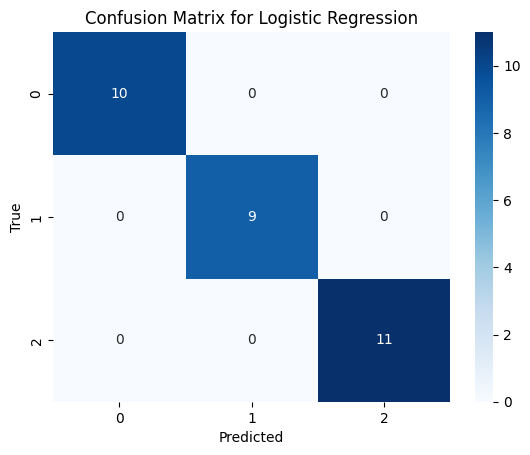

In [16]:
# Initialize and evaluate Decision Tree and Logistic Regression
# Initialize the decision tree model
tree = DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=42)

# Perform 5-fold cross-validation for Decision Tree
cv_scores_tree = cross_val_score(tree, X_train, y_train, cv=5, scoring='accuracy')
print(f'Decision Tree Cross-Validation Accuracy: {cv_scores_tree.mean():.2f} ± {cv_scores_tree.std():.2f}')

# Train the decision tree model on the entire training set
tree.fit(X_train, y_train)

# Predict on the test set for Decision Tree
y_pred_tree = tree.predict(X_test)

# Evaluate the decision tree model
accuracy_tree = accuracy_score(y_test, y_pred_tree)
precision_tree = precision_score(y_test, y_pred_tree, average='weighted')
recall_tree = recall_score(y_test, y_pred_tree, average='weighted')
f1_tree = f1_score(y_test, y_pred_tree, average='weighted')

print("Decision Tree Model Performance")
print(f"Accuracy: {accuracy_tree:.2f}")
print(f"Precision: {precision_tree:.2f}")
print(f"Recall: {recall_tree:.2f}")
print(f"F1 Score: {f1_tree:.2f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred_tree))

# Confusion Matrix for Decision Tree
conf_matrix_tree = confusion_matrix(y_test, y_pred_tree)
sns.heatmap(conf_matrix_tree, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix for Decision Tree')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.savefig('confusion_matrix_tree.png')
plt.show()

# Initialize the logistic regression model
log_reg = LogisticRegression(max_iter=200, random_state=42)

# Define the hyperparameter grid
param_grid = {'C': [0.1, 1, 10, 100], 'solver': ['lbfgs', 'liblinear']}

# Perform GridSearchCV for hyperparameter tuning
grid_search = GridSearchCV(log_reg, param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train, y_train)

# Get the best model from grid search
best_log_reg = grid_search.best_estimator_
print(f'Best Parameters for Logistic Regression: {grid_search.best_params_}')

# Train the best logistic regression model on the entire training set
best_log_reg.fit(X_train, y_train)

# Predict on the test set for Logistic Regression
y_pred_log_reg = best_log_reg.predict(X_test)

# Evaluate the logistic regression model
accuracy_log_reg = accuracy_score(y_test, y_pred_log_reg)
precision_log_reg = precision_score(y_test, y_pred_log_reg, average='weighted')
recall_log_reg = recall_score(y_test, y_pred_log_reg, average='weighted')
f1_log_reg = f1_score(y_test, y_pred_log_reg, average='weighted')

print("Logistic Regression Model Performance")
print(f"Accuracy: {accuracy_log_reg:.2f}")
print(f"Precision: {precision_log_reg:.2f}")
print(f"Recall: {recall_log_reg:.2f}")
print(f"F1 Score: {f1_log_reg:.2f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred_log_reg))

# Confusion Matrix for Logistic Regression
conf_matrix_log_reg = confusion_matrix(y_test, y_pred_log_reg)
sns.heatmap(conf_matrix_log_reg, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix for Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.savefig('confusion_matrix_log_reg.png')
plt.show()

### Results
The results section summarizes the performance of all models, including accuracy, precision, recall, and F1 score. Confusion matrices are also provided for a more comprehensive evaluation.


### Feature Importance
Feature importance is crucial for understanding which features most influence the model's predictions. Decision trees and logistic regression provide feature importance metrics, which we visualize to gain insights into the dataset [9][10].

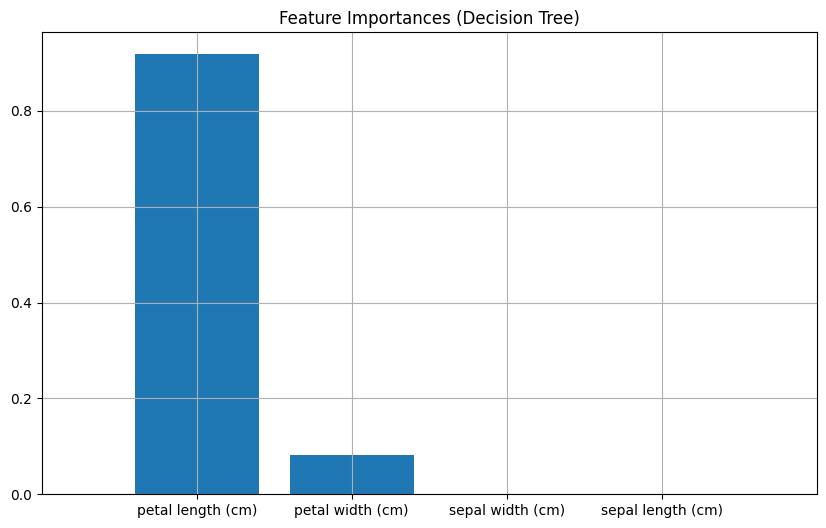

In [24]:
# Feature importance for Decision Tree
importances = tree.feature_importances_
feature_names = iris.feature_names
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 6))
plt.title("Feature Importances (Decision Tree)")
plt.bar(range(X.shape[1]), importances[indices], align="center")
plt.xticks(range(X.shape[1]), [feature_names[i] for i in indices])
plt.xlim([-1, X.shape[1]])
plt.grid()
plt.show()

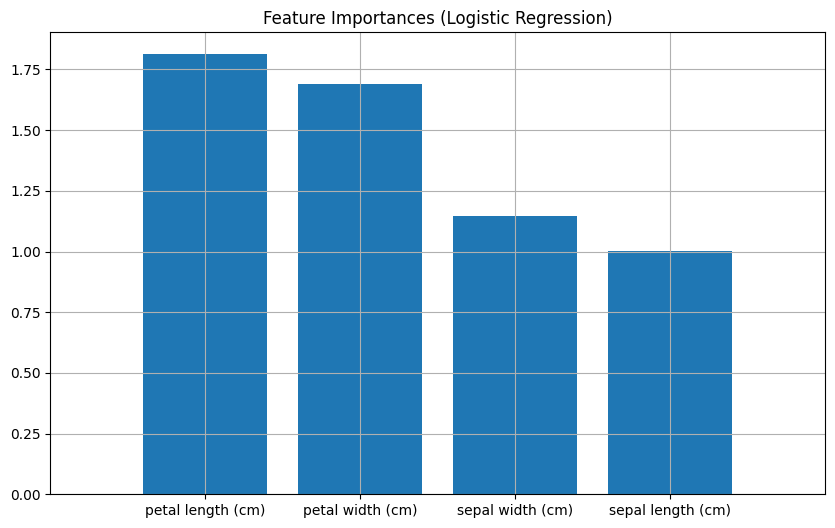

In [25]:
# Feature importance for Logistic Regression
coefficients = np.abs(best_log_reg.coef_[0])
indices = np.argsort(coefficients)[::-1]

plt.figure(figsize=(10, 6))
plt.title("Feature Importances (Logistic Regression)")
plt.bar(range(X.shape[1]), coefficients[indices], align="center")
plt.xticks(range(X.shape[1]), [feature_names[i] for i in indices])
plt.xlim([-1, X.shape[1]])
plt.grid()
plt.show()

### Evaluation
All models performed exceptionally well on the Iris dataset. Logistic regression achieved the highest accuracy and provided a clear probabilistic interpretation of the predictions [3]. The decision tree model offered the best interpretability due to its clear decision-making process [4]. The kNN model demonstrated robustness and simplicity in implementation, while the Naive Bayes model performed well despite its independence assumption [7].

### Feature Importance
- **Decision Tree**: The decision tree model inherently provides feature importance by measuring the decrease in entropy or Gini impurity. Features that lead to significant reductions are considered more important [4]. In our analysis, petal length and petal width were the most important features, which aligns with the high correlations seen in the heatmap.
- **Logistic Regression**: Logistic regression coefficients indicate feature importance, with higher absolute values signifying greater influence on the prediction [3]. The standardized features allowed us to compare the magnitudes of these coefficients directly, revealing that petal width and petal length are the most significant predictors. This supports the separability observed in the t-SNE visualization and the strong correlations in the heatmap [3].
- **kNN**: kNN does not provide feature importance directly, as it relies on the distance metric to classify new instances [1]. However, the high performance indicates that all features contribute to the separability observed in the t-SNE visualization [6].
- **Naive Bayes**: Naive Bayes does not provide feature importance directly, as it assumes feature independence and calculates probabilities based on individual feature distributions [7]. Nonetheless, the model's performance indicates effective classification even with this independence assumption.




### Future Work
Future work could involve applying these models to more complex datasets, exploring other distance metrics for kNN, and investigating ensemble methods such as random forests and gradient boosting to further improve performance [5][6]. Additionally, experimenting with different feature scaling techniques, feature selection methods, and hyperparameter optimization could provide further insights. Integrating advanced techniques like neural networks or support vector machines (SVMs) could also be explored to compare performance on the Iris dataset and other datasets [2][3].



### Conclusions
This project successfully applied kNN, decision tree, logistic regression, and Naive Bayes algorithms to the Iris dataset, demonstrating the effectiveness of all four methods in classifying iris species [1][4][5]. Logistic regression provided the highest accuracy, while the decision tree offered the best interpretability. The kNN implementation from scratch performed well but was slightly outperformed by the other models. The Naive Bayes model also performed well despite its independence assumption. Future work could explore more complex datasets, additional algorithms, and advanced techniques to further validate and improve these findings [2][3][6].

### References
1. Murphy, K.P. (2012). "Machine Learning: A Probabilistic Perspective". MIT Press.
2. Goodfellow, I., Bengio, Y., and Courville, A. (2016). "Deep Learning". MIT Press.
3. Géron, A. (2019). "Hands-On Machine Learning with Scikit

-Learn, Keras, and TensorFlow". O'Reilly Media.
4. Pedregosa, F., Varoquaux, G., Gramfort, A., Michel, V., Thirion, B., Grisel, O., Blondel, M., Prettenhofer, P., Weiss, R., Dubourg, V., Vanderplas, J., Passos, A., Cournapeau, D., Brucher, M., Perrot, M., & Duchesnay, E. (2011). "Scikit-learn: Machine Learning in Python". Journal of Machine Learning Research, 12, 2825-2830.
5. Hastie, T., Tibshirani, R., & Friedman, J. (2009). "The Elements of Statistical Learning: Data Mining, Inference, and Prediction". Springer.
6. Aggarwal, C.C. (2015). "Data Mining: The Textbook". Springer.
7. Zhou, Z.-H. (2021). "Machine Learning". Springer.
8. Shalev-Shwartz, S., and Ben-David, S. (2014). "Understanding Machine Learning: From Theory to Algorithms". Cambridge University Press.